<details><summary style="display:list-item; font-size:16px; color:blue;">Jupyter Help</summary>
    
Having trouble testing your work? Double-check that you have followed the steps below to write, run, save, and test your code!
    
[Click here for a walkthrough GIF of the steps below](https://static-assets.codecademy.com/Courses/ds-python/jupyter-help.gif)

Run all initial cells to import libraries and datasets. Then follow these steps for each question:
    
1. Add your solution to the cell with `## YOUR SOLUTION HERE ## `.
2. Run the cell by selecting the `Run` button or the `Shift`+`Enter` keys.
3. Save your work by selecting the `Save` button, the `command`+`s` keys (Mac), or `control`+`s` keys (Windows).
4. Select the `Test Work` button at the bottom left to test your work.

![Screenshot of the buttons at the top of a Jupyter Notebook. The Run and Save buttons are highlighted](https://static-assets.codecademy.com/Paths/ds-python/jupyter-buttons.png)

**Setup**

Run the setup cell to import the relevant libraries.

In [1]:
from transformers import BertConfig, BertModel, AutoTokenizer


**Checkpoint 1/3: Model config**

Print `config` to see what it looks like.

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

In [2]:
# Building the config
config = BertConfig()

## YOUR SOLUTION HERE ##
print(config)


BertConfig {
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.34.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



**Checkpoint 2/3: Building the model from config**

Print `model` to examine what a randomly instantiated model looks like.

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

In [3]:
# Building the model from the config
model = BertModel(config)

## YOUR SOLUTION HERE ##

print(model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

**Checkpoint 3/3: Tokenizers from model checkpoint**

Create a tokenizer, tokenizer with distilbert-base-uncased as the checkpoint. Tokenize the sample text provided (and be sure to print it!).

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

In [4]:
from transformers import AutoTokenizer

checkpoint = 'distilbert-base-uncased-finetuned-sst-2-english'
sample_text = ["BERT is an encoder-only transformer."]

## YOUR SOLUTION HERE ##

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

tokens = tokenizer(sample_text)

print(tokens)

{'input_ids': [[101, 14324, 2003, 2019, 4372, 16044, 2099, 1011, 2069, 10938, 2121, 1012, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


<details><summary style="display:list-item; font-size:16px; color:blue;">Want to know more about BERT?</summary>
    
Recall that there are three types of transformer models based on their architecture, i.e., whether they're encoder-only, decoder-only or encoder-decoder models. BERT is an encoder-only transformer model and it stands for Bidirectional Encoder Representations from Transformers. Attention layers in BERT have access to all the words in a sentence making the BERT class of models great at tasks that involve understanding an entire sentence such as sentence classification. 
    
The original BERT model was proposed in [2018](https://arxiv.org/abs/1810.04805) and had 340 million parameters. We've been using a much smaller model, [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english). We're going to learn more about this model in the upcoming exercise!

In [5]:
%matplotlib inline

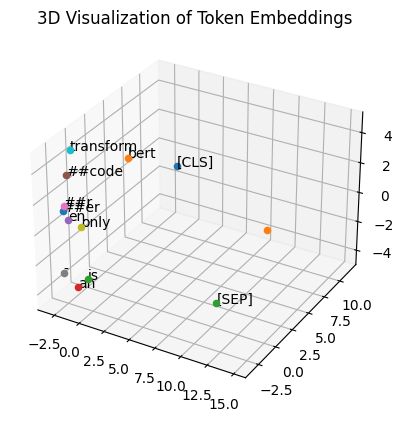

In [7]:
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Tokenize
inputs = tokenizer(sample_text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Get embeddings from model
with torch.no_grad():
    outputs = model(**inputs)
    hidden_states = outputs.last_hidden_state[0]   # shape: [seq_len, hidden_dim]

# Convert to numpy
embeddings = hidden_states.numpy()

# Reduce to 3 dimensions
pca = PCA(n_components=3)
coords = pca.fit_transform(embeddings)

# Plot in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

for i, token in enumerate(tokens):
    x, y, z = coords[i]
    ax.scatter(x, y, z)
    ax.text(x, y, z, token)

ax.set_title("3D Visualization of Token Embeddings")
plt.show()